In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal

In [2]:
class QuadState(TypedDict):

    a: int
    b: int
    c: int

    equation: str
    discriminant: float
    result: str

In [3]:
def show_equation(state: QuadState):
    equation = f'{state["a"]}x^2 + {state["b"]}x + {state["c"]}'
    return {'equation': equation}

In [4]:
def calculate_discriminant(state: QuadState):
    
    discriminant = state["b"]**2 - (4*state["a"]*state["c"])
    return {'discriminant': discriminant}


In [10]:
def real_roots(state: QuadState):

    root1 = (-state["b"] + state["discriminant"]**0.5)/(2*state["a"])
    root2 = (-state["b"] - state["discriminant"]**0.5)/(2*state["a"])

    result = f'The roots are {root1} and {root2}'
    return {'result': result}

In [11]:
def repeated_roots(state: QuadState):

    root = (-state["b"])/(2*state["a"])
    result = f'Only repeating root is {root}'

    return {'result': result}

In [ ]:
graph = StateGraph(QuadState)

graph.add_node('show_equation', show_equation)
graph.add_node('calculate_discriminant', calculate_discriminant)
graph.add_node('real_roots', real_roots)
graph.add_node('repeated_roots', repeated_roots)
graph.add_node('no_real_roots', no_real_roots)

graph.add_edge(START, 'show_equation')
graph.add_edge('show_equation', 'calculate_discriminant')
graph.add_edge('calculate_discriminant', END )

workflow = graph.compile()


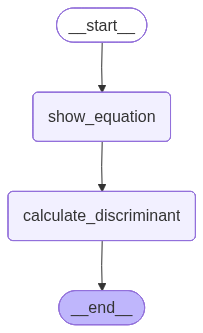

In [6]:
workflow

In [8]:
initial_state = {
    'a':4,
    'b': -5, 
    'c':-4
}
workflow.invoke(initial_state)

{'a': 4, 'b': -5, 'c': -4, 'equation': '4x^2 + -5x + -4', 'discriminant': 89}